# Rent model v1

Quick regression on the Kaggle house-rent data. log-transformed `Rent`, added a
locality feature, regularized with Ridge, tuned `alpha`. Scores look great - ready to ship.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("../01_regression_intro/data/House_Rent_Dataset.csv")

# average rent per locality - obviously a strong predictor, add it as a feature
df["locality_mean_rent"] = df.groupby("Area Locality")["Rent"].transform("mean")

num = ["BHK", "Size", "Bathroom", "locality_mean_rent"]
cat = ["City", "Furnishing Status", "Area Type"]
ohe = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
X = np.hstack([df[num].values, ohe.fit_transform(df[cat])])
y = np.log1p(df["Rent"].values)
feat_names = num + list(ohe.get_feature_names_out(cat))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("train:", X_train.shape, " test:", X_test.shape)

train: (3796, 13)  test: (950, 13)


In [2]:
# tune alpha: try a range, keep whichever scores best
best_alpha, best_score = None, -np.inf
for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    m = Ridge(alpha=alpha).fit(X_train, y_train)
    score = r2_score(y_test, m.predict(X_test))
    if score > best_score:
        best_alpha, best_score = alpha, score
print(f"best alpha = {best_alpha}  (test R2 = {best_score:.3f})")

final = Ridge(alpha=best_alpha).fit(X_train, y_train)

best alpha = 1.0  (test R2 = 0.847)


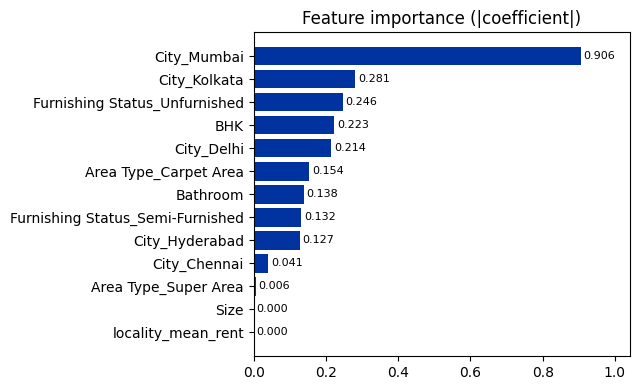

Top drivers: ['City_Mumbai', 'City_Kolkata', 'Furnishing Status_Unfurnished']
Barely matter: ['locality_mean_rent', 'Size', 'Area Type_Super Area']


In [3]:
# which features matter most? sort by coefficient magnitude
imp = pd.Series(np.abs(final.coef_), index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.barh(imp.index, imp.values, color="#0033A0")
ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.set_title("Feature importance (|coefficient|)")
ax.margins(x=0.15)
plt.tight_layout()
plt.show()
print("Top drivers:", list(imp.index[-3:][::-1]))
print("Barely matter:", list(imp.index[:3]))

In [4]:
# how good is it?
print(f"Train R2 = {r2_score(y_train, final.predict(X_train)):.3f}")

p = final.predict(X_test)
print(f"Test R2  = {r2_score(y_test, p):.3f}")
print(f"RMSE     = {mean_squared_error(y_test, p) ** 0.5:.3f}")
print(f"MAE      = {mean_absolute_error(y_test, p):.3f}")

# R2 on just the normal-priced flats
mask = y_test < np.log1p(100_000)
print(f"R2 (normal flats) = {r2_score(y_test[mask], p[mask]):.3f}")

# final number via cross-validation
cv = cross_val_score(Ridge(alpha=best_alpha), X_train, y_train,
                     cv=KFold(5, shuffle=True), scoring="neg_mean_squared_error")
print(f"\nFINAL CV MSE = {cv.mean():.3f}")

Train R2 = 0.829
Test R2  = 0.847
RMSE     = 0.361
MAE      = 0.276
R2 (normal flats) = 0.775

FINAL CV MSE = -0.154


Train and test R² both strong, error looks tiny, locality feature paid off. Shipping it. 🚀